<a href="https://colab.research.google.com/github/jbounellj/DC37-LaGua-DA/blob/main/Python%20Pro%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the corrected dataset
url = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv"

df = pd.read_csv(url)
df.head()



,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [2]:
df.columns



Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')

In [9]:
df["Performance"] = df["Percent Scoring 65 or Above"]


In [8]:
school = "BRONX HIGH SCHOOL OF SCIENCE"   # example
feature = "Percent Scoring 65 or Above"


In [11]:
baseline = df[df["School Name"] == school]
baseline


,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR,Performance


In [15]:
comparison_all = df[["School Name", "School Level", "School DBN",
                     "Regents Exam", feature]]
comparison_all.head()



,School Name,School Level,School DBN,Regents Exam,Percent Scoring 65 or Above
0,P.S. 034 Franklin D. Roosevelt,K-8,01M034,Common Core Algebra,s
1,P.S. 034 Franklin D. Roosevelt,K-8,01M034,Living Environment,93.8
2,P.S. 034 Franklin D. Roosevelt,K-8,01M034,Living Environment,88.9
3,P.S. 140 Nathan Straus,K-8,01M140,Common Core Algebra,s
4,P.S. 140 Nathan Straus,K-8,01M140,Common Core Algebra,s


In [18]:
df["Percent Scoring 65 or Above"]. describe()



,Percent Scoring 65 or Above
count,212331
unique,992
top,s
freq,75222


In [35]:
df_clean = df_clean[df_clean["Total Tested"] > 0]

df_clean["Percent Scoring 65 or Above"].describe()



,Percent Scoring 65 or Above
count,212331
unique,992
top,s
freq,75222


In [44]:
# --- CLEANING ---

df_clean = df.copy()

# Convert to numeric (fixes string values)
df_clean["Percent Scoring 65 or Above"] = pd.to_numeric(
    df_clean["Percent Scoring 65 or Above"], errors="coerce"
)

# Drop missing values
df_clean = df_clean.dropna(subset=["Percent Scoring 65 or Above"])

# Remove invalid percentages
df_clean = df_clean[
    (df_clean["Percent Scoring 65 or Above"] >= 0) &
    (df_clean["Percent Scoring 65 or Above"] <= 100)
]

# Optional: remove rows with zero test takers
df_clean = df_clean[df_clean["Total Tested"] > 0]

# --- DESCRIPTIVE STATISTICS ---

basic_stats = df_clean["Percent Scoring 65 or Above"].describe()
basic_stats



,Percent Scoring 65 or Above
count,137109.000000
mean,58.067855
std,28.405517
min,0.000000
25%,36.000000
50%,59.800000
75%,82.500000
max,100.000000


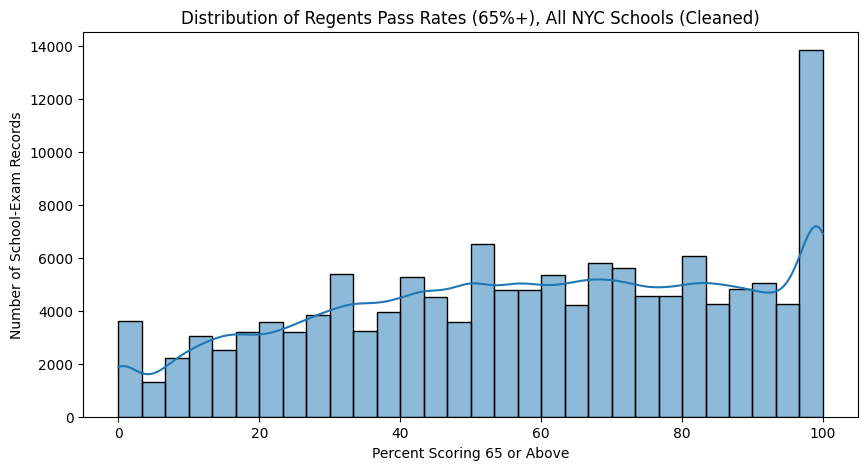

In [46]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean["Percent Scoring 65 or Above"], kde=True, bins=30)
plt.title("Distribution of Regents Pass Rates (65%+), All NYC Schools (Cleaned)")
plt.xlabel("Percent Scoring 65 or Above")
plt.ylabel("Number of School-Exam Records")
plt.show()

